In [1]:
import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
data_path = Path("..") / "data/engineered/training_pop30_genres.parquet"
df = pd.read_parquet(data_path)
print(f"Loaded {len(df):,} tracks from {data_path}")

Loaded 1,862,314 tracks from ../data/engineered/training_pop30_genres.parquet


# Data prep

## Categorical columns

In [4]:
from ast import literal_eval


df = df.astype(
    {
        "key": "category",
        "time_signature": "category",
        "release_season": "category",
        "album_type": "category",
    }
)
if pd.api.types.is_string_dtype(df["_artist_genres"]):
    df["_artist_genres"] = df["_artist_genres"].map(literal_eval)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862314 entries, 0 to 1862313
Data columns (total 26 columns):
 #   Column            Dtype   
---  ------            -----   
 0   track_rowid       int64   
 1   track_name        string  
 2   artist_name       string  
 3   artist_rowid      int64   
 4   album_rowid       int64   
 5   album_name        string  
 6   album_type        category
 7   _label            string  
 8   release_season    category
 9   artist_genres     string  
 10  _artist_genres    object  
 11  key               category
 12  time_signature    category
 13  mode              bool    
 14  tempo             float32 
 15  release_year      int32   
 16  danceability      float32 
 17  energy            float32 
 18  loudness          float32 
 19  speechiness       float32 
 20  acousticness      float32 
 21  instrumentalness  float32 
 22  liveness          float32 
 23  valence           float32 
 24  explicit          bool    
 25  duration_ms       

## Indexing labels

In [6]:
def build_label_vocab(labels: pd.Series):
    vocab = {}
    for label in labels.value_counts().index:
        if label not in vocab:
            vocab[label] = len(vocab)
    return vocab

label2idx = build_label_vocab(df["_label"])
print(f"Found {len(label2idx)} unique labels.")

Found 8363 unique labels.


## Indexing genre

In [7]:
from ast import literal_eval

def build_genre_vocab(genres: pd.Series):
    vocab = {}
    for genres in genres:
        for genre in genres:
            if genre not in vocab:
                vocab[genre] = len(vocab)
    return vocab

genre2idx = build_genre_vocab(df["_artist_genres"])
print(f"Found {len(genre2idx)} genres.")

Found 668 genres.


## Test-train split

In [8]:
ntrain = int(0.8 * len(df)); nvalid = len(df) - ntrain
_shuffled = df.sample(frac=1, replace=False, ignore_index=True, random_state=0)
dft = _shuffled.loc[:ntrain].reset_index()
dfv = _shuffled.loc[ntrain + 1: ].reset_index()

## Numerical feature standardization

In [9]:
def minmax(s: pd.Series, r: pd.Series | None=None, vrange:tuple[int, int]=(0, 1)) -> pd.Series:
    if r is None:
        r = s
    a, b = vrange
    return a + (s - r.min()) * (b - a) / (r.max() - r.min())

def zscore(s: pd.Series, r: pd.Series | None=None, mode: str = "mean"):
    if r is None:
        r = s
    if mode == "mean":
        m = r.mean()
    elif mode == "median":
        m = r.median()
    else:
        raise ValueError()
    return (s - m) / r.std()


ZSCORE_COLS = ["tempo", "duration_ms", "danceability", "energy", "loudness", "liveness", "valence"]
MINMAX_COLS = ["release_year", "speechiness", "acousticness", "instrumentalness"]

for col in ZSCORE_COLS:
  dfv[col] = zscore(dfv[col], dft[col], mode="median")
  dft[col] = zscore(dft[col], mode="median")

for col in MINMAX_COLS:
  dfv[col] = minmax(dfv[col], dft[col], vrange=(-1., 1.))
  dft[col] = minmax(dft[col], vrange=(-1., 1.))

In [10]:
if (_plot_train_correlations := False):
    features = [
        "tempo", "duration_ms", "release_year", "danceability", "energy",
        "loudness", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence",
    ]
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, n_feat, figsize=(12,12))
    
    for i in range(n_feat):
        for j in range(n_feat):
            ax = axes[i, j]
            if i == j:
                ax.hist(dft[features[i]], bins=30, color='steelblue', edgecolor='white')
            else:
                ax.hist2d(dft[features[j]], dft[features[i]], bins=30)
            
            if i == n_feat - 1:
                ax.set_xlabel(features[j], rotation=45, ha='right')
                ax.tick_params(axis='x', labelsize=7, rotation=45)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(features[i])
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Dataset

In [11]:
import torch
from torch.utils.data import Dataset
from torch.nn.functional import one_hot


class TrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label2idx: dict[str, int], genre2idx: dict[str, int]):
        # one-hot encoded
        self.album_type = one_hot(torch.tensor(df["album_type"].cat.codes.values, dtype=torch.long))
        self.release_season = one_hot(torch.tensor(df["release_season"].cat.codes.values, dtype=torch.long))
        self.time_signature = one_hot(torch.tensor(df["time_signature"].cat.codes.values, dtype=torch.long))
        self.key = one_hot(torch.tensor(df["key"].cat.codes.values, dtype=torch.long))
        # labels
        self.label = torch.tensor(df["_label"].map(label2idx).values, dtype=torch.long)
        # genres multi-hot
        self.genres = torch.zeros(len(df), len(genre2idx), dtype=torch.float32) # float32, it will feed a layer embedding
        for i, gs in enumerate(df["_artist_genres"]):
            for g in gs:
                self.genres[i, genre2idx[g]] = 1.
        # float variables
        self.floats = torch.tensor(
            df[[
                "release_year",
                "tempo",
                "danceability",
                "energy",
                "loudness",
                "speechiness",
                "acousticness",
                "instrumentalness",
                "liveness",
                "valence",
                "duration_ms",
            ]].values, 
            dtype=torch.float32
        )
        # bool variables
        self.bools = torch.tensor(
            df[[
                "mode",
                "explicit",
            ]].values,
            dtype=torch.bool,
        )

        self._len = len(df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        return (
            self.album_type[idx],
            self.release_season[idx],
            self.time_signature[idx],
            self.key[idx],
            self.label[idx],
            self.genres[idx],
            self.floats[idx],
            self.bools[idx],
        )

## Autoencoder

In [35]:
import torch
from torch import nn


class TrackAutoencoder(nn.Module):
    DIM_HIDDEN1 = 2048
    DIM_HIDDEN2 = 256
    DIM_LATENT = 16
    DIM_LABEL_EMBEDDING = 64

    DROPOUT = 0.
    
    def __init__(
        self, 
        num_labels: int, 
        num_genres: int, 
        num_album_type: int=3, 
        num_release_season: int=5,
        num_time_signature: int=5,
        num_key: int=12,
        num_floats: int=11,
        num_bools: int=2,
    ):
        super().__init__() 
        
        self.label_embedding = nn.Embedding(
            num_embeddings=num_labels, 
            embedding_dim=self.DIM_LABEL_EMBEDDING,
        )

        dim_inout = (
            num_album_type + num_release_season + num_time_signature +
            num_key + self.DIM_LABEL_EMBEDDING + num_genres + num_floats + num_bools
        )
        
        self.encoder = nn.Sequential(
            nn.Linear(dim_inout, self.DIM_HIDDEN1),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN1, self.DIM_HIDDEN2),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_LATENT),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.DIM_LATENT, self.DIM_HIDDEN2),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN1),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN1, dim_inout),
        )
    
    def forward(self, x: tuple[torch.Tensor, ...]):
        # you must embed before passing to forward. 
        # this way so that we can pass the same input to both loss and model.
        return self.decoder(self.encoder(x))

    def embed(self, ins: list[torch.Tensor, ...]) -> torch.Tensor:
        album_type, release_season, time_signature, key, label, genres, floats, bools = ins
        return torch.cat((
            album_type.float(),
            release_season.float(),
            time_signature.float(),
            key.float(),
            self.label_embedding(label),
            genres,
            floats,
            bools.float(),
        ), dim=1)
        
    def encode(self, ins: tuple[torch.Tensor, ...]):
        x = self.embed(ins)
        return self.encoder(x)

    def decode(self, y: torch.Tensor):
        return self.decoder(y)

## Training

In [33]:
from torch.utils.data import DataLoader
from torch import optim


print("Creating dataloaders..")
train_dataset, valid_dataset = TrackDataset(dft, label2idx, genre2idx), TrackDataset(dfv, label2idx, genre2idx)
train = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=20, pin_memory=True)
valid = DataLoader(valid_dataset, batch_size=1024, num_workers=20, pin_memory=True)

Creating dataloaders..


In [ ]:
import time

print("Initializing model..")
NEPOCHS, LR = 20, 5e-3
history = []
model = TrackAutoencoder(
    num_labels=len(label2idx), 
    num_genres=len(genre2idx),
    num_album_type=df["album_type"].cat.categories.size, 
    num_release_season=df["release_season"].cat.categories.size, 
    num_time_signature=df["time_signature"].cat.categories.size, 
    num_key=df["key"].cat.categories.size, 
    num_floats=11,
    num_bools=2,
)
device = torch.device("cuda")
model = model.to(device)
mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=1.0, patience=5)

t0 = time.time()
print(f"Training on {len(train_dataset)} rows..")
for epoch in range(NEPOCHS):
    model.train()
    total_loss = 0.
    for batch in train:
        batch = [x.to(device) for x in batch]
        xs = model.embed(batch)
        optimizer.zero_grad()
        zs = model(xs)
        loss = mse(xs, zs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    total_vloss = 0.
    with torch.no_grad():
        for batch in valid:
            batch = [x.to(device) for x in batch]
            xs = model.embed(batch)
            zs = model(xs)
            loss = mse(xs, zs)
            total_vloss += loss.item()
    # scheduler.step(total_vloss)
    history.append((total_loss / len(train), total_vloss / len(valid)))
    if epoch % (PRINT_EVERY := 1) == 0:
        # print(f"Epoch {epoch}, Train Loss: {history[-1][0]:.4f}, Valid Loss: {history[-1][1]:.4f} (LRf: {(_lrf := scheduler.get_last_lr()[0] / LR):.3f})")
        print(f"Epoch {epoch} (t={time.time() - t0:.2f}s), Train Loss: {history[-1][0]:.4f}, Valid Loss: {history[-1][1]:.4f}")
    # if _lrf < 0.001:
    #    break

Initializing model..
Training on 1489852 rows..
Epoch 0 (t=16.98s), Train Loss: 0.0278, Valid Loss: 0.0155


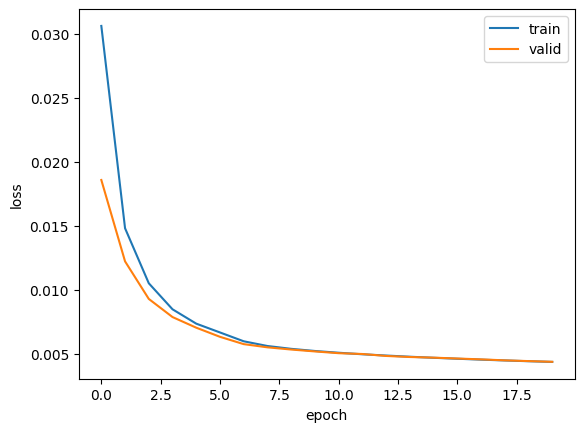

In [37]:
import matplotlib.pyplot as plt

train_loss, valid_loss = zip(*history)
plt.plot(train_loss, label="train")
plt.plot(valid_loss, label="valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

## Profiling

In [21]:
import time

print("Initializing model..")
NEPOCHS, LR = 20, 1e-3
history = []
model = TrackAutoencoder(
    num_labels=len(label2idx), 
    num_genres=len(genre2idx),
    num_album_type=df["album_type"].cat.categories.size, 
    num_release_season=df["release_season"].cat.categories.size, 
    num_time_signature=df["time_signature"].cat.categories.size, 
    num_key=df["key"].cat.categories.size, 
    num_floats=11,
    num_bools=2,
)
device = torch.device("cuda")
model = model.to(device)
mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Time one epoch breakdown
data_time, forward_time, backward_time = 0, 0, 0

t0 = time.time()
for batch in train:
    data_time += time.time() - t0
    
    t1 = time.time()
    batch = [x.to(device) for x in batch]
    xs = model.embed(batch)
    zs = model(xs)
    loss = mse(xs, zs)
    forward_time += time.time() - t1
    
    t2 = time.time()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    backward_time += time.time() - t2
    
    t0 = time.time()

print(f"Data: {data_time:.2f}s, Forward: {forward_time:.2f}s, Backward: {backward_time:.2f}s")

Initializing model..
Data: 1.71s, Forward: 3.92s, Backward: 5.17s
